# Records Matching

DS 6105 | Summer 2026

**Know Their Names Capstone**

## Set Up

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
# import duckdb # Using this for joins
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, HTML

In [2]:
# con = duckdb.connect()

## Read

### MENTION

We import the mentions data, dropping all the super-low entropy columns, i.e. where only one value exists, or they are all nulls.

In [63]:
mention_file = "../data/sources/all_mentions.csv"
mention_cols_to_drop = ['original_data','created','county','narrative','maiden_name','location_id'] #'death_year','location_id','source_year','source'] 
MENTION = (
    pd.read_csv(mention_file, low_memory=False)
    .set_index('mention_id')
    .drop(mention_cols_to_drop, axis=1)
    .drop_duplicates()
)

MENTION['birth_year'] = MENTION.birth_year.astype('Int64')
MENTION.loc[MENTION.birth_year < 1000, 'birth_year'] = np.nan

## Define a Person Key that includes the enslavers last name as property of nameless enslaved

MENTION['enslaver_name'] = (
        MENTION.reset_index()
        .merge(MENTION.reset_index(), left_on='enslaver_id', right_on='mention_id')
    ).set_index('mention_id_x').full_name_y

def make_key_str(x):
    person_str = (
        "-".join([str(v) for v in x[:-1]])
        .lower()
        .replace(" ", "_")
        .replace("nan", "X")
        .replace("<na>", "XXXX")
    )
    # Add enslaver as property of enslaved
    if not pd.isna(x.enslaver_name):
        try:
            person_str += f"@{x.enslaver_name.lower().replace(" ", "_")}"
        except AttributeError as e:
            print(e)
            print(type(x.enslaver_name))
            print(x.enslaver_name)
    return person_str
    
key_cols = ['birth_year', 'norm_race', 'gender', 'full_name','enslaver_name']
MENTION['person_key'] = MENTION[key_cols].apply(make_key_str, axis=1)

In [61]:
MENTION[~MENTION.enslaver_id.isna()].person_key.value_counts()

person_key
1846-b-m-X@john_s_cocke      3
1845-b-m-X@l_w_maupin        2
1854-b-m-X@w_w_miner         2
1859-b-m-X@a_w_gantt         2
XXXX-b-m-X@j_w_elsom         2
                            ..
1852-b-f-X@peter_keister     1
1852-b-m-X@peter_keister     1
1853-b-f-X@frances_thomas    1
1856-b-f-X@frances_thomas    1
1859-b-m-X@frances_thomas    1
Name: count, Length: 6769, dtype: int64

### ASSERTION

In [333]:
assertion_file = "../data/sources/all_assertions.csv"
assertion_cols_to_drop = ['created','object_string','county']
ASSERTION = (
    pd.read_csv(assertion_file, low_memory=False)
    .drop(assertion_cols_to_drop, axis=1)
    .merge(MENTION.reset_index(), left_on='subject_id', right_on='mention_id')
    .merge(MENTION.reset_index(), left_on='object_id', right_on='mention_id')
)
ASSERTION

,assertion_id,subject_id,predicate,object_id,start_year,end_year,who,confidence_x,mention_id_x,source_x,...,norm_first_name_y,nysiis_last_name_y,norm_race_y,norm_occupation_y,enslaver_id_y,head_y,household_id_y,family_id_y,enslaver_name_y,person_key_y
0,bb358496-2b77-4c22-b95d-bb21aad0e70f,354884aa-76f6-4bee-87b4-fa4c3e459ad7,isSiblingOf,db93ea35-d868-42bd-aadd-c58d9c7c3303,1880,NaN,expanded,0.9,354884aa-76f6-4bee-87b4-fa4c3e459ad7,ALB_CN_1880,...,FRANCIS,BERR,W,DOMESTIC,NaN,f,NaN,FC1880-4815,NaN,1872-w-f-francis_j_berry
1,fc5b8f22-0916-47e2-82ec-599634b5165f,126439b9-4304-4428-8071-7bb60929b572,isSiblingOf,594ea5c6-e25e-478f-8581-27b7a3f09477,1870,NaN,1870Census,0.5,126439b9-4304-4428-8071-7bb60929b572,ALB_CN_1870,...,MARGARET,BATE,B,WASH WOMAN,NaN,f,HC1870-30,FC1870-30,NaN,1849-b-f-margaret_bates
2,cc0233a4-97b7-42be-8e52-5856124c7ad9,594ea5c6-e25e-478f-8581-27b7a3f09477,isSiblingOf,73f2a8d2-4184-4bf0-bc60-68ebf491927a,1870,NaN,1870Census,0.5,594ea5c6-e25e-478f-8581-27b7a3f09477,ALB_CN_1870,...,HENRY,BATE,B,AGRICULTURE,NaN,f,HC1870-30,FC1870-30,NaN,1854-b-m-henry_bates
3,52a6c078-1355-40b6-95cc-b4d3ff6f17c9,73f2a8d2-4184-4bf0-bc60-68ebf491927a,isSiblingOf,ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d,1870,NaN,1870Census,0.5,73f2a8d2-4184-4bf0-bc60-68ebf491927a,ALB_CN_1870,...,WILLIAM,BATE,B,NaN,NaN,f,HC1870-30,FC1870-30,NaN,1864-b-m-wm_bates
4,1a7aa6a5-bcfe-4836-94b4-85952722b8a3,ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d,isSpouseOf,49d22c94-b8be-455b-9b70-f8f1fdfd393d,1870,NaN,1870Census,0.5,ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d,ALB_CN_1870,...,ANN,BATE,B,NaN,NaN,f,HC1870-30,FC1870-30,NaN,1869-b-f-anna_bates
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60981,de3c482e-3665-4048-9ff9-f12773852ec9,ade94449-e624-437c-9f5f-cdc6886c00bb,isGrandChildOf,dc46e55b-55b5-40dd-9524-4a1163aa9e68,1870,NaN,expanded,0.5,ade94449-e624-437c-9f5f-cdc6886c00bb,ALB_CN_1870,...,SALLIE,BROW,W,DOMESTIC,NaN,f,HC1870-1989,FC1870-4010,NaN,1838-w-f-sallie_j_brown
60982,0051b07e-b3f9-463a-9d62-d145207858ba,6c751426-70af-437a-a8c5-5f5c67df8e63,isGrandChildOf,dc11d064-ce0e-4a10-a08b-df27603a591b,1870,NaN,expanded,0.5,6c751426-70af-437a-a8c5-5f5c67df8e63,ALB_CN_1870,...,MARY,SCHA,W,DOMESTIC,NaN,f,HC1870-744,FC1870-2769,NaN,1837-w-f-mary_schackelford
60983,e9d93ed4-0c2d-49b5-8127-5edf20dfe069,515776a2-d84d-430a-81ad-629c0763ffe4,isGrandChildOf,533b6d17-f6db-4b80-af9a-3bd58a177792,1870,NaN,expanded,0.5,515776a2-d84d-430a-81ad-629c0763ffe4,ALB_CN_1870,...,FANNIE,DAVI,W,DOMESTIC,NaN,f,HC1870-1898,FC1870-3919,NaN,1841-w-f-fannie_davis
60984,b945c258-fa10-4d54-9dd5-cfaed1522252,64de42b6-5f02-4bc3-800a-29ae687987bc,isGrandChildOf,433fca7b-47a5-48e4-be57-7c84eac487b0,1870,NaN,expanded,0.5,64de42b6-5f02-4bc3-800a-29ae687987bc,ALB_CN_1870,...,ROSE,HEND,B,DOMESTIC,NaN,f,HC1870-576,FC1870-2601,NaN,1798-b-f-rose_henderson


In [335]:
ASSERTION.predicate = ASSERTION.predicate.str.replace(r"(Nibling|Pibling)", "Sibling", regex=True)
ASSERTION.predicate = ASSERTION.predicate.str.lower().str.replace(r"^(is|was)", "", regex=True).str.replace(r"(by|of)$", "_to", regex=True)
ASSERTION.predicate.value_counts()

predicate
sibling_to         18425
child_to           12604
parent_to          12604
enslaved_to         6870
spouse_to           4520
grandparent_to      1890
grandchild_to       1890
mother_to           1001
father_to            943
siblinginlaw_to       84
parentinlaw_to        63
childinlaw_to         57
cousin_to             25
grandmother_to         9
grandfather_to         1
Name: count, dtype: int64

## Transform

### MENTION $\rightarrow$ PERSON

In [336]:
PERSON = MENTION.value_counts('person_key').to_frame('n_mentions')
PERSON['mention_ids'] = MENTION.reset_index().groupby('person_key').mention_id.apply(lambda x: list(x))

In [338]:
PERSON.sample(10)

,n_mentions,mention_ids
person_key,,
1833-b-f-judith_grove,1,[1e3cf576-fe61-4424-a34f-f0c0f4d20c1a]
1864-b-f-cinthie_robison,1,[73a79e23-df2a-4d20-93e3-ac5b5d189639]
1842-w-m-james_fisher,1,[efed036e-f19c-4f63-968c-10e5912cdb2c]
1867-w-f-regina_good,1,[1d27cf55-8c0b-4a52-b1f9-6c2cfe72e692]
1817-b-m-X@m_l_walker,1,[eee7a696-48c8-4e48-95c3-723a235ad9f4]
1875-w-m-burel_good,1,[0c0c363a-23f2-442a-a9e3-b08b696db3f3]
1832-w-m-wm_day,1,[f8ae566a-e746-4cdf-b4a2-92efb4195e38]
XXXX-X-f-mary_janny,1,[fab01f45-4be8-4973-89a6-3cc4734f68ff]
1850-b-m-william_simms,1,[69c04332-adad-4d8c-a9d4-8db468d64923]


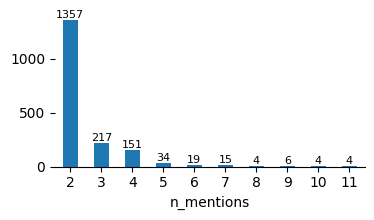

In [339]:
ax = PERSON[PERSON.n_mentions > 1].n_mentions.value_counts().sort_index().head(10).plot.bar(figsize=(4,2), rot=0)
ax.bar_label(ax.containers[0], fontsize=8)
sns.despine(left=True)
plt.show()

### ASSERTION $\rightarrow$ RELATION

In [341]:
RELATION = ASSERTION.value_counts(['person_key_x','predicate','person_key_y']).to_frame('n')
RELATION.index.names = ['subject_key','predicate','object_key']
RELATION

,,,n
subject_key,predicate,object_key,
1846-b-m-X@john_s_cocke,enslaved_to,XXXX-X-X-john_s_cocke,3
1849-w-m-charles_dudley,sibling_to,1852-w-m-jerry_dudley,2
1861-w-m-eugene_brown,spouse_to,1863-w-f-annie_brown,2
XXXX-X-m-solomon_pasley,father_to,XXXX-X-X-lofton_pasley,2
1857-b-m-X@wm_j_earley,enslaved_to,XXXX-X-X-wm_j_earley,2
...,...,...,...
1864-w-f-cora_l_brown,grandchild_to,1838-w-f-sallie_j_brown,1
1865-w-m-charles_shackelford,grandchild_to,1837-w-f-mary_schackelford,1
1864-w-f-henrietta_davis,grandchild_to,1841-w-f-fannie_davis,1


In [342]:
RELATION.n.value_counts(normalize=True)

n
1    0.998275
2    0.001708
3    0.000016
Name: proportion, dtype: float64

### Add RELATION counts to PERSON

In [343]:
RELATION

,,,n
subject_key,predicate,object_key,
1846-b-m-X@john_s_cocke,enslaved_to,XXXX-X-X-john_s_cocke,3
1849-w-m-charles_dudley,sibling_to,1852-w-m-jerry_dudley,2
1861-w-m-eugene_brown,spouse_to,1863-w-f-annie_brown,2
XXXX-X-m-solomon_pasley,father_to,XXXX-X-X-lofton_pasley,2
1857-b-m-X@wm_j_earley,enslaved_to,XXXX-X-X-wm_j_earley,2
...,...,...,...
1864-w-f-cora_l_brown,grandchild_to,1838-w-f-sallie_j_brown,1
1865-w-m-charles_shackelford,grandchild_to,1837-w-f-mary_schackelford,1
1864-w-f-henrietta_davis,grandchild_to,1841-w-f-fannie_davis,1


In [344]:
PERSON['n_relations'] = RELATION.reset_index().subject_key.value_counts()
PERSON.n_relations = PERSON.n_relations.fillna(0)
PERSON.n_relations = PERSON.n_relations.astype(int)

In [345]:
PERSON['n_relations_as_object'] = RELATION.reset_index().object_key.value_counts()
PERSON.n_relations_as_object = PERSON.n_relations_as_object.fillna(0)
PERSON.n_relations_as_object = PERSON.n_relations_as_object.astype(int)

In [346]:
PERSON.sort_values('n_relations', ascending=False)

,n_mentions,mention_ids,n_relations,n_relations_as_object
person_key,,,,
1820-b-m-wm_carter,2,"[d0323ff2-ebba-46a1-8d65-b8ad906e8cd7, abb8f6b...",13,14
XXXX-X-f-mary,28,"[551120f7-197e-4e1f-8525-0d7b511f7dc7, f3f7214...",12,0
1830-w-m-j_b_evans,1,[1d71fa68-f7b2-4a85-9503-aeb9934117e7],12,13
1853-w-f-ann_t_gregory,1,[58e7f9c8-6159-4636-9818-02850fd67448],12,1
1828-w-m-andy_e_gregory,1,[a90a6285-4406-4325-b075-72b85216936a],12,13
...,...,...,...,...
XXXX-X-X-oura,1,[40d1dbe8-387a-49e4-aa98-67b2c55b0c31],0,0
XXXX-X-X-wornly,1,[f46302da-adf9-4bd9-8610-1645eed2cee4],0,2
1824-X-X-john_worlds,1,[19f167ec-fcbc-4762-a28b-a96a9aa740a8],0,0


### Interactive Tools

In [347]:
p = RELATION.sample().index[0][0]
print(p, ":", sep="")
try:
    relations = RELATION.loc[p].sort_index().reset_index().values
    for rel in relations:
        print("-- ", end="")
        print(rel[0], rel[1], sep="\t")
except KeyError as e:
    print("-- Has no recorded relations.")

1830-w-m-john_lotts:
-- parent_to	1868-w-f-bjane_lotts
-- parent_to	1870-w-f-julia_a_lotts
-- parent_to	1872-w-m-george_w_lotts
-- parent_to	1875-w-f-fannie_f_lotts
-- parent_to	1878-w-f-mary_l_lotts


In [348]:
person_auto_widget = widgets.Combobox(
    value=PERSON.sample().index[0],
    options=PERSON.index.to_list(),
    description='Person ID:',
    continuous_update=False
)
@interact(person_id=person_auto_widget)
def view_person(person_id):
    mention_cols = ['source', 'source_year', 'household_id', 'family_id', 'norm_occupation']
    display(HTML(f"<h3>Person ID: {person_id.replace("_", " ").replace("-", " ").title()}</h3>"))
    try:
        person = PERSON.loc[person_id]
    except KeyError as e:
        display(HTML("<tt>Try again.</tt>"))
        return None
    test_ids = person.mention_ids
    display(MENTION.loc[test_ids].sort_values('source_year')[mention_cols].T.dropna().T)
    try:
        display(HTML("<hr />"))
        display(RELATION.loc[person_id])
    except KeyError as e:
        display(HTML("No relations found."))

interactive(children=(Combobox(value='1792-b-m-wilson_smith', continuous_update=False, description='Person ID:…

## Save

In [317]:
MENTION.to_parquet("../data/MENTION.parquet", index=True)
ASSERTION.to_parquet("../data/ASSERTION.parquet", index=True)
MENTION_ASSERTION.to_parquet("../data/MENTION_ASSERTION.parquet", index=True)
PERSON.to_parquet("../data/PERSON.parquet", index=True)
RELATION.to_parquet("../data/RELATION.parquet", index=True)

## Explore

### Distribution of Source Years

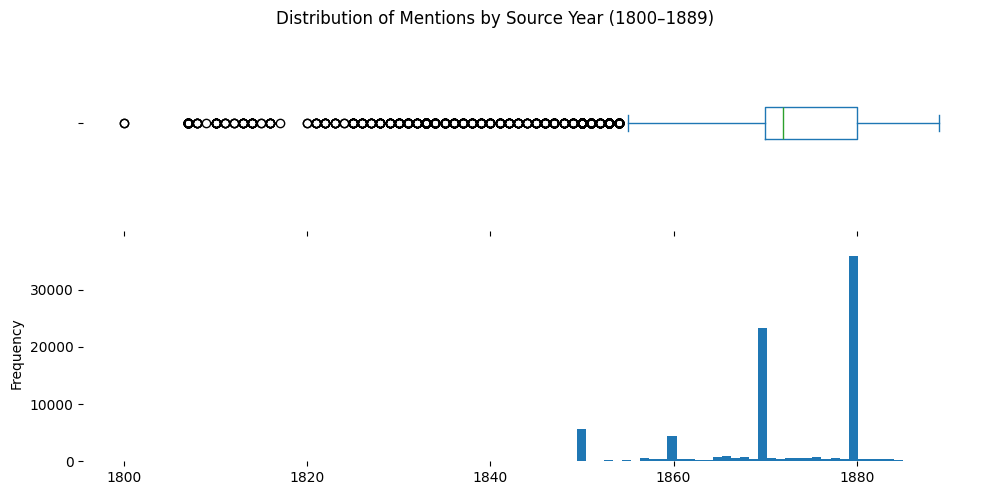

In [216]:
date_range = (MENTION.source_year >= 1800) & (MENTION.source_year < 1890)
X = MENTION[date_range].source_year

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,5))

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=90)

axes[0].set_yticklabels("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.suptitle("Distribution of Mentions by Source Year (1800–1889)")
plt.show()

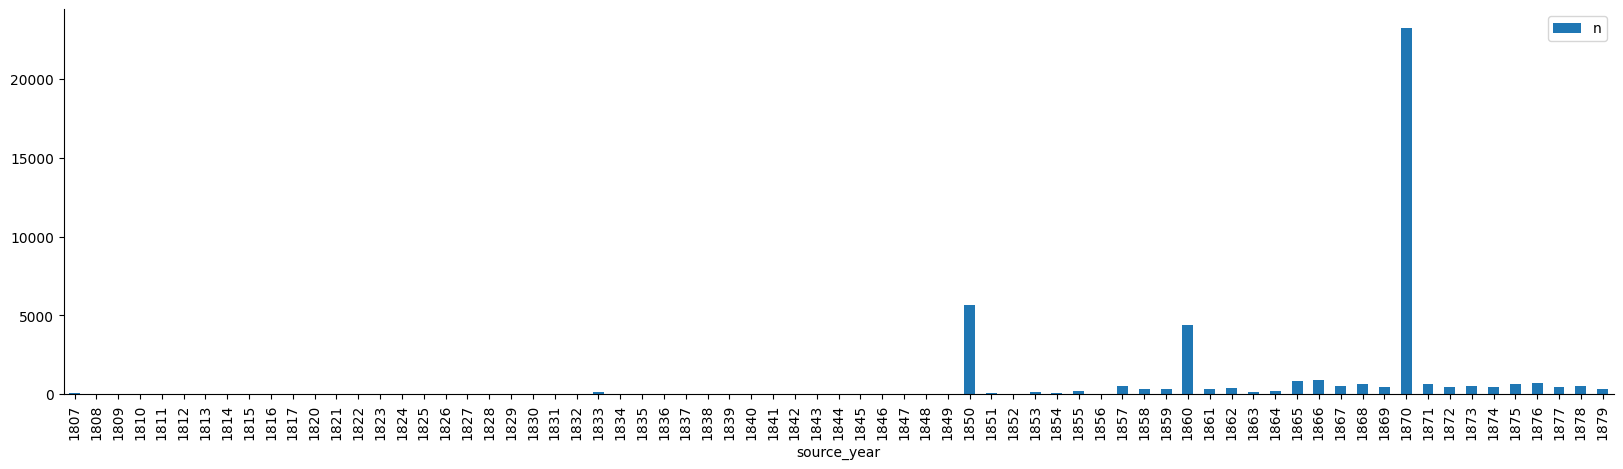

In [217]:
(
    MENTION[(MENTION.source_year > 1800) & (MENTION.source_year < 1880)]
    .value_counts('source_year')
    .to_frame('n')
    .sort_index()
    .plot.bar(figsize=(20,5))
)
sns.despine()

### Distribution of Birth Years

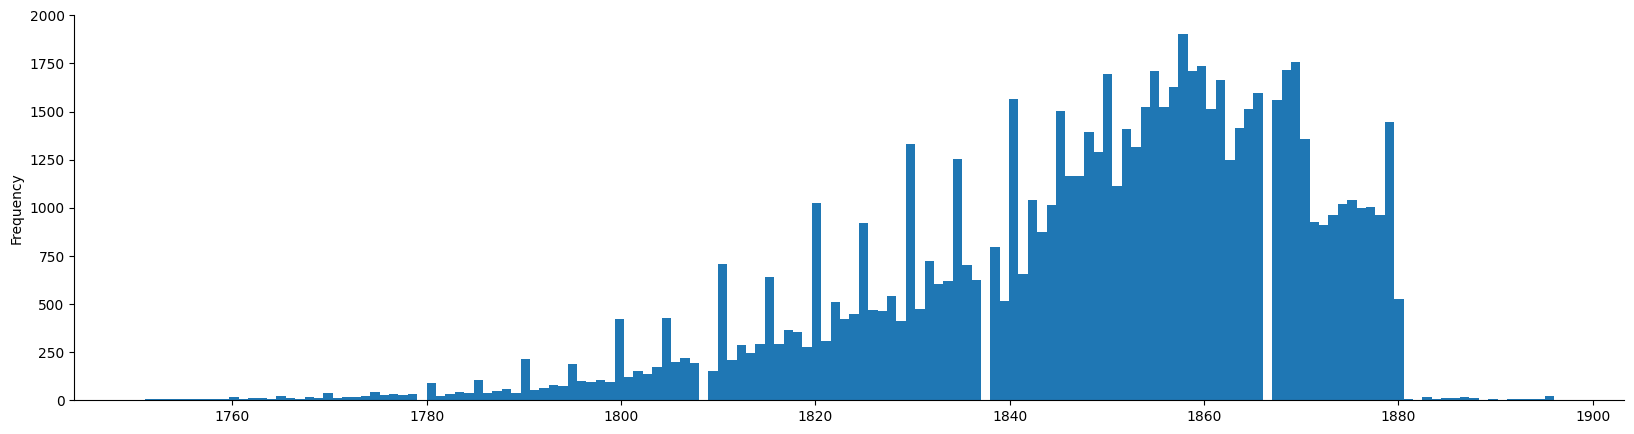

In [218]:
MENTION[MENTION.birth_year > 1750].birth_year.plot.hist(bins=150, figsize=(20,5))
sns.despine()
plt.show()

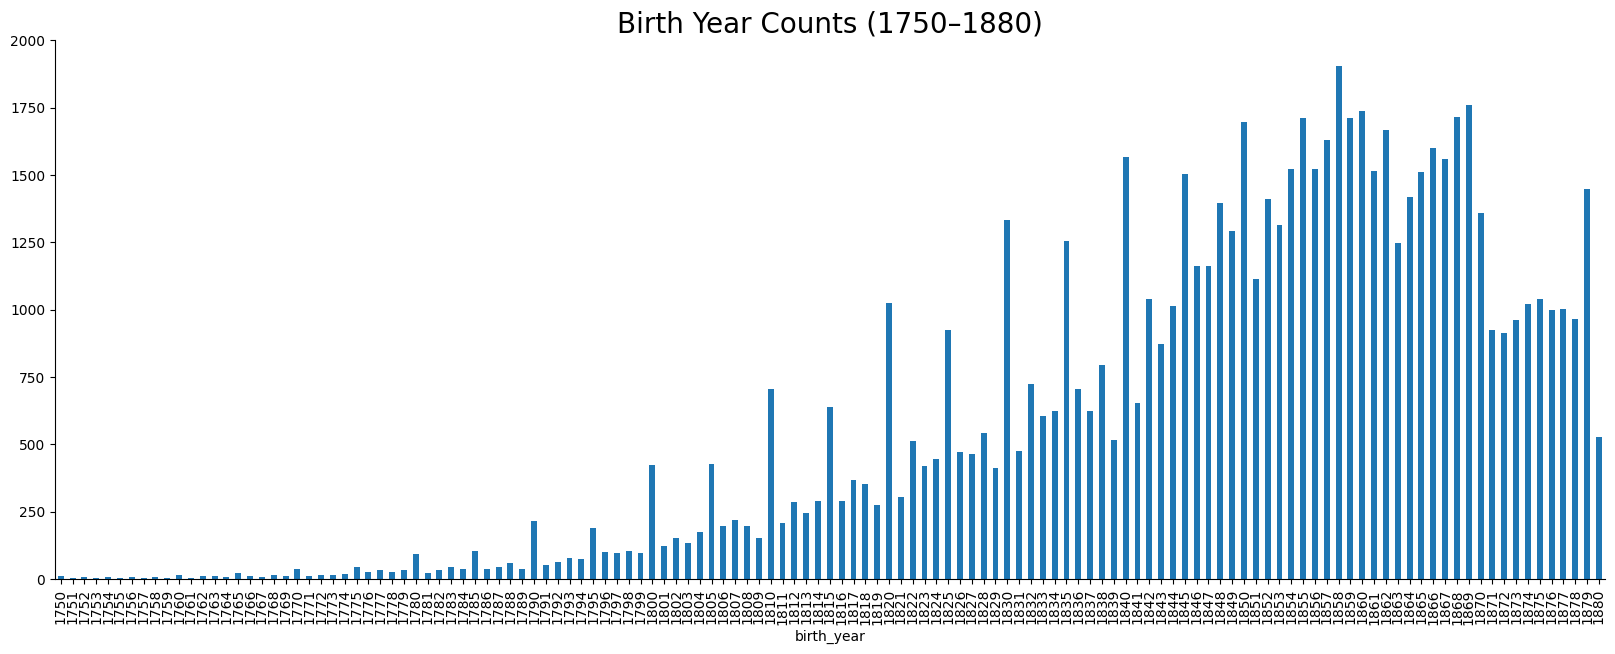

In [219]:
X = MENTION[(MENTION.birth_year >= 1750) & (MENTION.birth_year < 1881)].birth_year.value_counts().sort_index()
X.plot.bar(x='birth_year', y='n', figsize=(20,7))
plt.title("Birth Year Counts (1750–1880)", fontsize=20)
sns.despine()
plt.show()

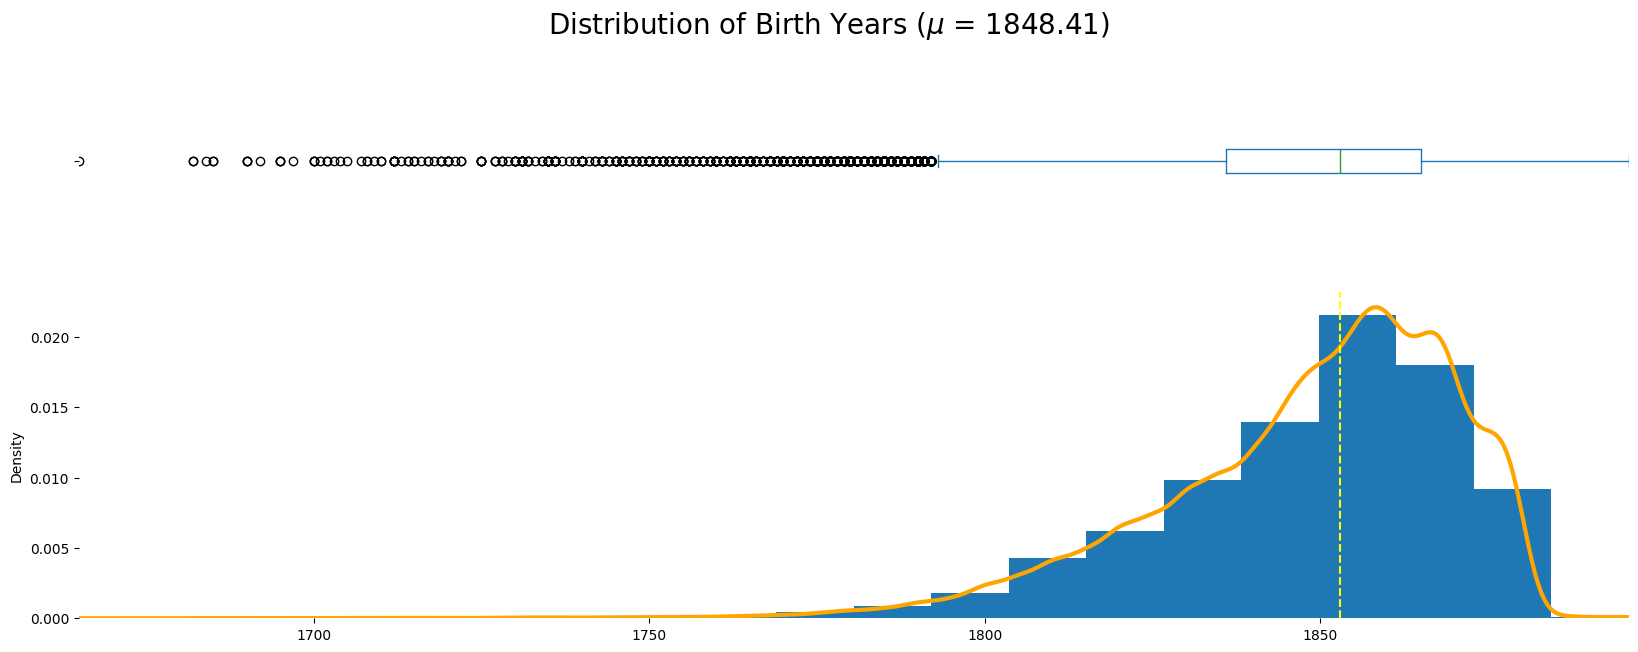

In [220]:
X = MENTION.loc[MENTION.birth_year > 188, 'birth_year']

fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]})

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=20, density=True)
X.plot.kde(ax=axes[1], color='orange', lw=3)

axes[0].set_yticklabels([])
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axes[1].axvline(X.median(), color='yellow', ls='--')
axes[0].set_xlim(X.min(), X.max())
axes[1].set_xlim(X.min(), X.max())

sns.despine(left=True, bottom=True)
plt.suptitle(rf"Distribution of Birth Years ($\mu$ = {MENTION.birth_year.mean().round(2)})", fontsize=20)
plt.show()